## Project 8: Customer Segmentation

In [1]:
# Framework: Discovering Hidden Behavior Clusters via Unsupervised Learning

In [2]:
# Discover hidden patterns

# Create customer profiles

# Segment customers using clustering

# Provide business recommendations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")

In [2]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 3 rows:")
df.head(3)

Shape: (200, 5)

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

First 3 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


##  Discover Hidden Pattern

In [3]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print("SUMMARY STATS ")
print(df[['Age', 'Annual_Income', 'Spending_Score']].describe().round(2))

print("\n CORRELATIONS ")
print(df[['Age', 'Annual_Income', 'Spending_Score']].corr().round(2))

SUMMARY STATS 
          Age  Annual_Income  Spending_Score
count  200.00         200.00          200.00
mean    38.85          60.56           50.20
std     13.97          26.26           25.82
min     18.00          15.00            1.00
25%     28.75          41.50           34.75
50%     36.00          61.50           50.00
75%     49.00          78.00           73.00
max     70.00         137.00           99.00

 CORRELATIONS 
                 Age  Annual_Income  Spending_Score
Age             1.00          -0.01           -0.33
Annual_Income  -0.01           1.00            0.01
Spending_Score -0.33           0.01            1.00


## Creating customers profile

In [4]:
profiles = df.groupby('Gender')[['Age', 'Annual_Income', 'Spending_Score']].agg(['mean', 'median', 'std']).round(2)
profiles

Age               Annual_Income               Spending_Score         \
         mean median    std          mean median    std           mean median   
Gender                                                                          
Female  38.10   35.0  12.64         59.25   60.0  26.01          51.53   50.0   
Male    39.81   37.0  15.51         62.23   62.5  26.64          48.51   50.0   

               
          std  
Gender         
Female  24.11  
Male    27.90

## Segmenting customers using clustering

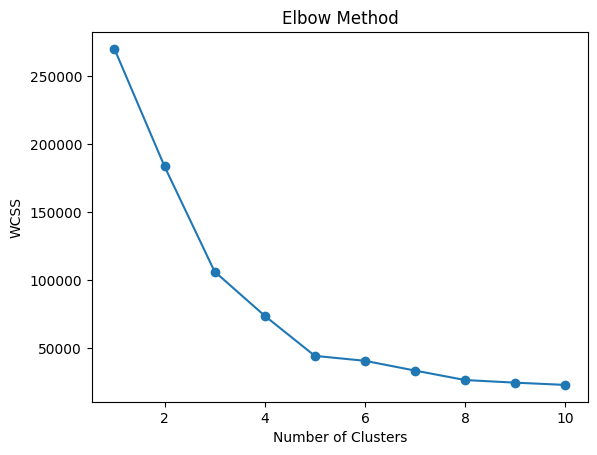

In [5]:
# Finding Optimal Clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual_Income', 'Spending_Score']]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
# Training K-Means & Assign Segments
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("Customer count per cluster:")
print(df['Cluster'].value_counts().sort_index())

Customer count per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## recommendations

In [7]:
recommendations = {
    "Cluster 0 (High Income, High Spending)": "VIP loyalty perks, concierge services, exclusive brand previews.",
    "Cluster 1 (High Income, Low Spending)": "Targeted premium offers emphasizing product quality and value.",
    "Cluster 2 (Average Income, Average Spending)": "Standard seasonal promotions and cross-selling everyday catalog items.",
    "Cluster 3 (Low Income, High Spending)": "Trend-driven micro-promotions, flash sales, and rewards points.",
    "Cluster 4 (Low Income, Low Spending)": "Low-cost marketing touchpoints like automated email discounts."
}

for segment, strategy in recommendations.items():
    print(f"{segment}:\n -> {strategy}\n")

Cluster 0 (High Income, High Spending):
 -> VIP loyalty perks, concierge services, exclusive brand previews.

Cluster 1 (High Income, Low Spending):
 -> Targeted premium offers emphasizing product quality and value.

Cluster 2 (Average Income, Average Spending):
 -> Standard seasonal promotions and cross-selling everyday catalog items.

Cluster 3 (Low Income, High Spending):
 -> Trend-driven micro-promotions, flash sales, and rewards points.

Cluster 4 (Low Income, Low Spending):
 -> Low-cost marketing touchpoints like automated email discounts.

